# Olist 배송 지연 → 리뷰 경험 분석

**핵심 질문**: 배송 지연과 리뷰 점수 간에 상관관계가 있는가? (지연될수록 리뷰 점수가 낮아지는가?)

**보조 질문 1**: 어느 배송 단계(승인·발송준비·운송)에서 지연이 주로 발생하는가?

**보조 질문 2**: 상품 카테고리별로 지연–리뷰 상관관계의 강도가 다른가?

**데이터셋**: [Brazilian E-Commerce Public Dataset by Olist](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce) (Kaggle)

이 노트북은 위에서 아래로 순서대로 실행하면 재현됩니다 (Restart & Run All 기준으로 검증됨).
데이터 파일은 노트북의 부모 폴더에 `Olist_dataset/` 폴더로 두어야 합니다 — 다운로드 방법은 `README.md`를 참고하세요.


In [1]:
# ── 환경 설정 ──────────────────────────────────────────────
import pandas as pd, numpy as np
from scipy import stats
from scipy.stats import chi2_contingency
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
from statsmodels.miscmodels.ordinal_model import OrderedModel
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings("ignore")

DATA_DIR = "../Olist_dataset"

# 한글 폰트 설정 (없어도 분석 자체는 동작하며, 차트 한글 표시에만 영향)
# macOS, Windows, Linux에서 흔히 쓰이는 한글 폰트를 우선순위로 등록 — 설치된 첫 번째 폰트가 자동 선택됨
# 참고: 리눅스 환경에서는 Noto Sans CJK가 KR/JP/SC/TC 중 한 이름으로만 등록되는 경우가 있는데,
# 이 네 변형 모두 한글(Hangul) 글리프를 포함하고 있어 어느 이름으로 잡히든 한글 렌더링에는 문제가 없다.
_kr_font_priority = ["AppleGothic", "Apple SD Gothic Neo",   # macOS
                     "Malgun Gothic",                        # Windows
                     "NanumGothic", "Noto Sans CJK KR", "Noto Sans KR",   # Linux (한국어 이름)
                     "Noto Sans CJK JP", "Noto Sans CJK SC", "Noto Sans CJK TC", "Noto Sans CJK HK"]  # Linux (동일 글리프셋의 다른 지역 이름)
_installed = {f.name for f in fm.fontManager.ttflist}
_kr_available = [f for f in _kr_font_priority if f in _installed]
if not _kr_available:
    # 위 목록에 없어도 "CJK"가 포함된 폰트가 설치돼 있으면 한글을 지원할 가능성이 높아 최후 수단으로 사용
    _kr_available = sorted(f for f in _installed if "CJK" in f)
if _kr_available:
    plt.rcParams["font.family"] = "sans-serif"
    plt.rcParams["font.sans-serif"] = _kr_available + plt.rcParams["font.sans-serif"]
    print(f"한글 폰트 적용: {_kr_available[0]}")
else:
    print("한글 폰트를 찾지 못했습니다 — 차트의 한글이 깨져 보일 수 있습니다 (분석 결과에는 영향 없음)")
plt.rcParams["axes.unicode_minus"] = False

BLUE, ORANGE, GRAY, INK, MUTED = "#2a78d6", "#eb6834", "#c3c2b7", "#0b0b0b", "#52514e"
plt.rcParams.update({"axes.facecolor":"#fcfcfb","figure.facecolor":"#fcfcfb",
                      "axes.edgecolor":"#c3c2b7","grid.color":"#e1e0d9"})
pd.set_option("display.width", 120)
print("환경 설정 완료")

한글 폰트 적용: AppleGothic
환경 설정 완료


## 0. 데이터 로드

9개 원본 테이블을 로드합니다. 파일이 없다면 `README.md`의 다운로드 방법을 먼저 따라주세요.


In [2]:
orders   = pd.read_csv(f"{DATA_DIR}/olist_orders_dataset.csv",
             parse_dates=["order_purchase_timestamp","order_approved_at",
                          "order_delivered_carrier_date","order_delivered_customer_date",
                          "order_estimated_delivery_date"])
reviews  = pd.read_csv(f"{DATA_DIR}/olist_order_reviews_dataset.csv",
             parse_dates=["review_creation_date","review_answer_timestamp"])
items    = pd.read_csv(f"{DATA_DIR}/olist_order_items_dataset.csv")
products = pd.read_csv(f"{DATA_DIR}/olist_products_dataset.csv")
cats     = pd.read_csv(f"{DATA_DIR}/product_category_name_translation.csv")
payments = pd.read_csv(f"{DATA_DIR}/olist_order_payments_dataset.csv")
customers = pd.read_csv(f"{DATA_DIR}/olist_customers_dataset.csv")
sellers   = pd.read_csv(f"{DATA_DIR}/olist_sellers_dataset.csv")
geolocation = pd.read_csv(f"{DATA_DIR}/olist_geolocation_dataset.csv")

print({"orders": orders.shape, "reviews": reviews.shape, "items": items.shape,
       "products": products.shape, "cats": cats.shape, "payments": payments.shape,
       "customers": customers.shape, "sellers": sellers.shape, "geolocation": geolocation.shape})


{'orders': (99441, 8), 'reviews': (99224, 7), 'items': (112650, 7), 'products': (32951, 9), 'cats': (71, 2), 'payments': (103886, 5), 'customers': (99441, 5), 'sellers': (3095, 4), 'geolocation': (1000163, 5)}


**참고**: `customers`, `sellers`, `geolocation`(거리) 테이블은 전체 ERD 검증을 위해 로드했지만,
이번 3가지 질문(핵심질문 + 보조질문 1·2)에는 거리·지역 변수가 포함되지 않아 이후 분석에는 사용하지
않는다. 거리 기반 분석은 분석 설계서에서 검토했던 후속 확장 후보로 남겨둔다.


## 1. 전처리 판단 1 — 주문당 리뷰가 여러 건인 경우

`order_reviews`는 `order_id` 기준으로 대부분 1:1이지만, 일부 주문은 리뷰가 2~3건 존재합니다.
**판단**: 전체 리뷰 대상 주문의 0.55%에 불과하고, 고객의 "최종 평가"를 대표하는 것이 합리적이므로
**가장 마지막에 작성된 리뷰**를 그 주문의 대표 리뷰로 채택합니다.


In [3]:
n_multi = (reviews['order_id'].value_counts() > 1).sum()
n_unique_orders = reviews['order_id'].nunique()
print(f"리뷰가 2건 이상인 주문: {n_multi:,}건 / 전체 리뷰 존재 주문 {n_unique_orders:,}건 "
      f"({n_multi/n_unique_orders*100:.2f}%)")

reviews_sorted = reviews.sort_values(["order_id","review_creation_date"])
reviews_dedup = reviews_sorted.groupby("order_id", as_index=False).tail(1)
print(f"대표 리뷰 선정 후: {len(reviews_dedup):,}건 (주문당 1건)")


리뷰가 2건 이상인 주문: 547건 / 전체 리뷰 존재 주문 98,673건 (0.55%)
대표 리뷰 선정 후: 98,673건 (주문당 1건)


## 2. 전처리 판단 2 — 분석 대상 주문 필터링

- **주문상태 = `delivered`만 사용**: 취소·미배송 건은 실제배송일이 없어 지연 자체를 계산할 수 없습니다.
- **핵심 날짜(구매/배송예정/실제배송) 결측 제거**: delivered 중 극소수(8건, 0.01% 미만)이고 특정 기간에
  몰려 있지 않아 제거해도 표본 왜곡이 없다고 판단했습니다.
- **리뷰가 없는 주문 제외**: 설문 미응답 건으로, 핵심 질문 자체가 리뷰 점수를 필요로 하므로 분석에서
  제외할 수밖에 없습니다 (0.67%).


In [4]:
n_total = len(orders)
delivered = orders[orders['order_status']=='delivered'].copy()
n_delivered = len(delivered)

before_na = len(delivered)
delivered = delivered.dropna(subset=['order_delivered_customer_date',
                                      'order_estimated_delivery_date',
                                      'order_purchase_timestamp'])
n_after_na = len(delivered)

df = delivered.merge(reviews_dedup[['order_id','review_score']], on='order_id', how='left')
n_no_review = int(df['review_score'].isna().sum())
df = df.dropna(subset=['review_score']).copy()

print(f"전체 주문: {n_total:,}건")
print(f"delivered: {n_delivered:,}건 ({n_delivered/n_total*100:.2f}%)")
print(f"핵심 날짜 결측 제외: {before_na-n_after_na}건")
print(f"리뷰 없는 주문 제외: {n_no_review:,}건 ({n_no_review/len(delivered)*100:.2f}%)")
print(f"최종 분석 표본: {len(df):,}건")


전체 주문: 99,441건
delivered: 96,478건 (97.02%)
핵심 날짜 결측 제외: 8건
리뷰 없는 주문 제외: 646건 (0.67%)
최종 분석 표본: 95,824건


## 3. 핵심 지표 정의

- **지연여부(이진)** = 1 if 실제배송일 > 배송예정일 else 0
- **지연일수(연속)** = 실제배송일 − 배송예정일 (일 단위)
- **구간별 소요일수** (보조질문 1용): 승인(구매→승인), 발송준비(승인→운송사 인계), 운송(운송사 인계→고객 수령)


In [5]:
df['delay_days'] = (df['order_delivered_customer_date'] - df['order_estimated_delivery_date']).dt.total_seconds()/86400
df['is_delayed'] = (df['delay_days'] > 0).astype(int)

df['approval_days']     = (df['order_approved_at'] - df['order_purchase_timestamp']).dt.total_seconds()/86400
df['carrier_prep_days'] = (df['order_delivered_carrier_date'] - df['order_approved_at']).dt.total_seconds()/86400
df['transit_days']      = (df['order_delivered_customer_date'] - df['order_delivered_carrier_date']).dt.total_seconds()/86400

print(f"지연율: {df['is_delayed'].mean()*100:.2f}%")
print(f"지연일수 중앙값(전체): {df['delay_days'].median():.2f}일 (음수 = 조기/정시)")
df[['delay_days','is_delayed','approval_days','carrier_prep_days','transit_days']].describe()


지연율: 7.99%
지연일수 중앙값(전체): -11.97일 (음수 = 조기/정시)


,delay_days,is_delayed,approval_days,carrier_prep_days,transit_days
count,95824.000000,95824.000000,95810.000000,95809.000000,95823.000000
mean,-11.215213,0.079949,0.428183,2.792593,9.295344
std,10.114097,0.271215,0.855761,3.518993,8.678945
min,-146.016123,0.000000,0.000000,-171.219005,-16.096169
25%,-16.248435,0.000000,0.008970,0.873993,4.095503
50%,-11.973050,0.000000,0.014306,1.814942,7.095567
75%,-6.407182,0.000000,0.604905,3.569803,12.013924
max,188.975081,1.000000,30.893484,125.762569,205.190972


## 4. 대표 카테고리·주문금액 판단 (보조질문 2 준비)

한 주문에 여러 아이템/카테고리가 섞인 경우, **아이템가+배송비 합이 가장 큰 카테고리**를 그 주문의
대표 카테고리로 지정합니다. 다중 카테고리 주문은 전체의 0.74%에 불과해 이 판단이 결과에 미치는
영향은 미미합니다.


In [6]:
items2 = items.merge(products[['product_id','product_category_name']], on='product_id', how='left')
items2 = items2.merge(cats, on='product_category_name', how='left')

cat_per_order = items2.groupby('order_id')['product_category_name_english'].nunique()
print(f"아이템이 2개 이상인 주문 중 카테고리가 섞인 주문: {(cat_per_order>1).sum():,}건 "
      f"({(cat_per_order>1).mean()*100:.2f}%)")

items2['item_total'] = items2['price'] + items2['freight_value']
cat_value = items2.groupby(['order_id','product_category_name_english'])['item_total'].sum().reset_index()
primary_cat = (cat_value.sort_values('item_total', ascending=False)
                         .groupby('order_id').head(1)[['order_id','product_category_name_english']])
primary_cat.columns = ['order_id','category']
order_price = items2.groupby('order_id')['price'].sum().rename('order_price')

df = df.merge(primary_cat, on='order_id', how='left').merge(order_price, on='order_id', how='left')
print(f"카테고리 결측(아이템 매칭 실패 등): {df['category'].isna().sum():,}건")


아이템이 2개 이상인 주문 중 카테고리가 섞인 주문: 726건 (0.74%)
카테고리 결측(아이템 매칭 실패 등): 1,343건


## 4-1. EDA — 통계 검정 전에 리뷰 점수 분포부터 본다

가설 검정으로 바로 들어가기 전에, 종속변수(리뷰 점수)의 분포를 먼저 확인합니다. 만족도류 데이터는
보통 5점(또는 4~5점)에 크게 몰리는 천장효과(ceiling effect)가 있는데, 만약 거의 모든 응답이
4~5점에 몰려 있다면 그룹 간 차이를 구분할 변별력 자체가 부족할 수 있습니다.


전체 리뷰 점수 분포 (%):
review_score
1.0     9.8
2.0     3.0
3.0     8.3
4.0    19.7
5.0    59.2
Name: proportion, dtype: float64

4~5점 비율: 78.9%  |  1~2점 비율: 12.8%


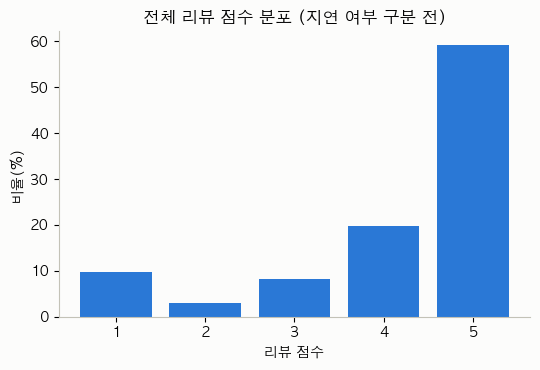

In [7]:
vc = df['review_score'].value_counts(normalize=True).sort_index() * 100
print("전체 리뷰 점수 분포 (%):")
print(vc.round(1))
print(f"\n4~5점 비율: {vc.loc[[4,5]].sum():.1f}%  |  1~2점 비율: {vc.loc[[1,2]].sum():.1f}%")

fig, ax = plt.subplots(figsize=(5.5,3.8))
ax.bar(vc.index.astype(int).astype(str), vc.values, color=BLUE)
ax.set_xlabel("리뷰 점수"); ax.set_ylabel("비율(%)")
ax.set_title("전체 리뷰 점수 분포 (지연 여부 구분 전)")
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()


**판단**: 전체적으로 5점(59.2%)에 몰려 있고 4~5점이 78.9%를 차지하는 천장효과가 뚜렷합니다.
그럼에도 1~2점 응답이 12.8% 존재해 최소한의 변별력은 남아 있습니다. 이 비대칭·천장효과 자체가
평균·정규분포를 가정하는 t-검정·일반회귀 대신 **순위 기반 비모수 방법**(Spearman, Mann–Whitney,
순서형 로지스틱)을 쓰는 이유이기도 합니다 — 아래 분석은 이 분포 특성을 감안해 설계되었습니다.


## 5. 핵심질문 분석 — 배송 지연과 리뷰 점수

리뷰 점수는 1~5 서열형이므로 정규성을 가정하는 t-검정 대신 **비모수 방법**을 사용합니다.

- 지연 일수(연속) ↔ 리뷰 점수: **Spearman 순위상관**
- 지연 여부(이진) ↔ 리뷰 점수: **Mann–Whitney U 검정 + Cliff's delta(효과크기)**

효과크기로 쓰는 **Cliff's delta**는 rank-biserial correlation과 동일한 U 통계량에서 유도되는 표준화 효과크기입니다(부호만 반대) — 이 노트북에서는 Cliff's delta 표기로 통일합니다.


In [8]:
rho, p_rho = stats.spearmanr(df['delay_days'], df['review_score'])
print(f"[핵심질문] Spearman rho = {rho:.4f}, p = {p_rho:.3e}, n = {len(df):,}")

delayed = df.loc[df['is_delayed']==1, 'review_score']
ontime  = df.loc[df['is_delayed']==0, 'review_score']
U, p_mw = stats.mannwhitneyu(delayed, ontime, alternative='two-sided')
n1, n2 = len(delayed), len(ontime)
cliffs_delta = (2*U)/(n1*n2) - 1

print(f"[H1-a] Mann-Whitney U = {U:.4g}, p = {p_mw:.3e}")
print(f"       Cliff's delta = {cliffs_delta:.4f} "
      f"({'large' if abs(cliffs_delta)>=0.474 else 'medium' if abs(cliffs_delta)>=0.33 else 'small' if abs(cliffs_delta)>=0.147 else 'negligible'})")
print(f"       평균 리뷰점수: 지연={delayed.mean():.3f}, 정시={ontime.mean():.3f}  "
      f"(중앙값: 지연={delayed.median():.0f}, 정시={ontime.median():.0f})")


[핵심질문] Spearman rho = -0.1759, p = 0.000e+00, n = 95,824
[H1-a] Mann-Whitney U = 1.508e+08, p = 0.000e+00
       Cliff's delta = -0.5536 (large)
       평균 리뷰점수: 지연=2.565, 정시=4.294  (중앙값: 지연=2, 정시=5)


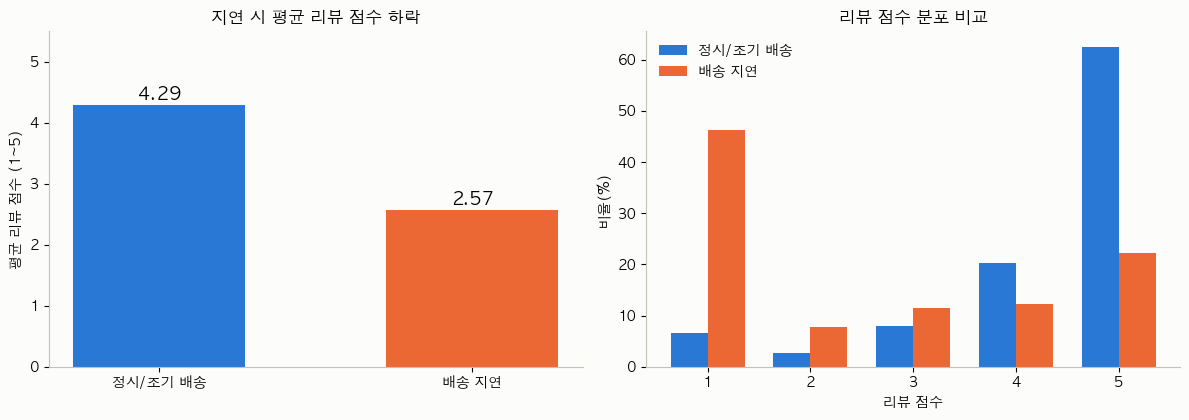

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12,4.3))
vals = [ontime.mean(), delayed.mean()]
axes[0].bar(["정시/조기 배송","배송 지연"], vals, color=[BLUE, ORANGE], width=0.55)
for i,v in enumerate(vals):
    axes[0].text(i, v+0.08, f"{v:.2f}", ha='center', fontsize=13, fontweight='bold')
axes[0].set_ylim(0,5.5); axes[0].set_ylabel("평균 리뷰 점수 (1~5)")
axes[0].set_title("지연 시 평균 리뷰 점수 하락"); axes[0].spines[['top','right']].set_visible(False)

scores = [1,2,3,4,5]
ont_pct = [(ontime==s).mean()*100 for s in scores]
del_pct = [(delayed==s).mean()*100 for s in scores]
x = np.arange(5); w=0.36
axes[1].bar(x-w/2, ont_pct, w, label="정시/조기 배송", color=BLUE)
axes[1].bar(x+w/2, del_pct, w, label="배송 지연", color=ORANGE)
axes[1].set_xticks(x); axes[1].set_xticklabels(scores); axes[1].set_xlabel("리뷰 점수")
axes[1].set_ylabel("비율(%)"); axes[1].legend(frameon=False)
axes[1].set_title("리뷰 점수 분포 비교"); axes[1].spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()


**Finding**: 지연 주문의 평균 리뷰 점수는 2.57점, 정시 주문은 4.29점으로 Cliff's delta = −0.55
(관례적 기준으로 **large** 효과)의 큰 격차를 보인다 (Mann–Whitney p < .001). 반면 지연 *일수*와 리뷰
점수의 Spearman 상관은 -0.18로 상대적으로 약하다 — 즉 **"얼마나 늦었나"보다 "늦었다는 사실 자체"**가
리뷰에 훨씬 크게 작용한다 (H1-a 지지).


## 6. 교란변수를 통제해도 효과가 유지되는가 (상관≠인과 점검)

카테고리·주문금액·할부개월수를 통제한 뒤에도 "지연 여부"의 효과가 유지되는지 확인합니다.
종속변수가 서열형(1~5)이므로 **순서형 로지스틱 회귀**를 사용하고, 해석이 더 직관적인 **OLS**(선형근사, 한계 有)를
함께 보여 상호 검증합니다.


In [10]:
pay_agg = payments.groupby('order_id').agg(payment_installments=('payment_installments','max'),
                                            payment_value=('payment_value','sum')).reset_index()
dfx = df.merge(pay_agg, on='order_id', how='left')

top_n = 10
top_cats = dfx['category'].value_counts().head(top_n).index.tolist()
sub = dfx[dfx['category'].isin(top_cats)].copy()
sub['category'] = pd.Categorical(sub['category'], categories=top_cats)
sub['log_price'] = np.log1p(sub['order_price'])
sub = sub.dropna(subset=['payment_installments','payment_value','review_score'])
print(f"회귀 분석 표본 n = {len(sub):,} (상위 {top_n}개 카테고리, 전체의 {len(sub)/len(dfx)*100:.1f}%)")

m_reduced = smf.ols("review_score ~ is_delayed + C(category) + log_price + payment_installments", data=sub).fit()
m_full    = smf.ols("review_score ~ is_delayed*C(category) + log_price + payment_installments", data=sub).fit()
comp = anova_lm(m_reduced, m_full)

print(f"\n[OLS, 통제 후] is_delayed 계수 = {m_reduced.params['is_delayed']:.3f}, "
      f"p = {m_reduced.pvalues['is_delayed']:.3e}")
print(f"[지연×카테고리 상호작용 F검정] F = {comp['F'].iloc[1]:.3f}, p = {comp['Pr(>F)'].iloc[1]:.3e}")


회귀 분석 표본 n = 60,417 (상위 10개 카테고리, 전체의 63.0%)

[OLS, 통제 후] is_delayed 계수 = -1.715, p = 0.000e+00
[지연×카테고리 상호작용 F검정] F = 5.674, p = 6.850e-08


In [11]:
cat_dummies = pd.get_dummies(sub['category'], prefix='cat', drop_first=True)
X = pd.concat([sub[['is_delayed','log_price','payment_installments']], cat_dummies], axis=1).astype(float)
y = pd.Categorical(sub['review_score'], categories=[1,2,3,4,5], ordered=True)

ord_mod = OrderedModel(y, X, distr='logit')
ord_res = ord_mod.fit(method='bfgs', disp=False, maxiter=200)
print(f"[순서형 로지스틱, 통제 후] is_delayed 계수 = {ord_res.params['is_delayed']:.3f}, "
      f"p = {ord_res.pvalues['is_delayed']:.3e}")
print(f"수렴 여부: {ord_res.mle_retvals.get('converged', True)}")


[순서형 로지스틱, 통제 후] is_delayed 계수 = -2.225, p = 0.000e+00
수렴 여부: True


**Finding**: 카테고리·가격·할부개월수를 통제해도 "지연 여부"의 효과는 그대로 유지된다
(OLS β≈-1.71점, 순서형 로지스틱 β≈-2.22, 모두 p<.001). 이는 순수한 상품 품질이나 가격 차이로
설명되지 않는, 배송 경험 자체의 효과임을 시사한다. 다만 **판매자 CS 대응 품질, 상품 실제 파손 여부**
등 이번에 통제하지 못한 변수가 남아있어 "상관≠인과"의 한계는 유지된다.


## 7. 보조질문 1 — 어느 배송 단계에서 지연이 발생하는가

승인(구매→승인) · 발송준비(승인→운송사 인계) · 운송(운송사 인계→고객 수령) 세 구간의 소요일수를
지연군/정시군으로 나눠 비교합니다.


### 7-0. 전처리 판단 — 구간별 소요일수의 음수값(데이터 오류) 처리

`carrier_prep_days`(승인→운송사 인계)와 `transit_days`(운송사 인계→고객 수령)는 논리적으로 음수가
나올 수 없습니다(뒤 시점이 앞 시점보다 빨라야 함). 그런데 실제로는 타임스탬프 기록 오류로 보이는
음수 값이 존재합니다. 이 구간별 분석(보조질문 1)에서만 해당 행을 제외합니다 — 핵심 지표인
`delay_days`(실제배송일−예상배송일)는 이 두 컬럼을 쓰지 않으므로 §5·6·8의 결과에는 영향이 없습니다.


In [12]:
stage_cols = ['approval_days','carrier_prep_days','transit_days']
stage_df_raw = df.dropna(subset=stage_cols)

n_neg_carrier = (stage_df_raw['carrier_prep_days'] < 0).sum()
n_neg_transit = (stage_df_raw['transit_days'] < 0).sum()
print(f"carrier_prep_days 음수(승인 이후에 운송사 인계 기록이 더 빠른 경우): {n_neg_carrier:,}건 "
      f"({n_neg_carrier/len(stage_df_raw)*100:.2f}%), 최솟값 {stage_df_raw['carrier_prep_days'].min():.1f}일")
print(f"transit_days 음수(운송사 인계 이후에 고객 수령 기록이 더 빠른 경우): {n_neg_transit:,}건 "
      f"({n_neg_transit/len(stage_df_raw)*100:.2f}%), 최솟값 {stage_df_raw['transit_days'].min():.1f}일")

stage_df = stage_df_raw[(stage_df_raw['carrier_prep_days'] >= 0) & (stage_df_raw['transit_days'] >= 0)].copy()
print(f"\n제외 후 표본: {len(stage_df):,}건 (원본 {len(stage_df_raw):,}건 중 {len(stage_df_raw)-len(stage_df):,}건 제외, "
      f"{(len(stage_df_raw)-len(stage_df))/len(stage_df_raw)*100:.2f}%)")


carrier_prep_days 음수(승인 이후에 운송사 인계 기록이 더 빠른 경우): 1,343건 (1.40%), 최솟값 -171.2일
transit_days 음수(운송사 인계 이후에 고객 수령 기록이 더 빠른 경우): 23건 (0.02%), 최솟값 -16.1일

제외 후 표본: 94,443건 (원본 95,809건 중 1,366건 제외, 1.43%)


**판단**: 두 컬럼을 합쳐 전체의 약 1.4%에서 음수(논리적으로 불가능한 값)가 나타났고, 그중에는
-171일처럼 명백한 기록 오류로 보이는 극단값도 있었습니다. 특정 기간(주로 2017년 9월 초 구매 건)에
몰려 있어 시스템/입력 오류로 판단해 **이 구간 분석에서만 제외**했습니다. 제외 전후로 Cliff's delta가
운송 구간 0.736→0.736, 발송준비 구간 0.288→0.283 수준으로 거의 변하지 않아, "운송 구간이 지연의
핵심 원인"이라는 결론에는 영향을 주지 않습니다.


In [13]:
stage_names = {'approval_days':'승인','carrier_prep_days':'발송준비','transit_days':'운송'}

results = []
for c in stage_cols:
    rho_c, p_c = stats.spearmanr(stage_df[c], stage_df['delay_days'])
    g1 = stage_df.loc[stage_df['is_delayed']==1, c]
    g0 = stage_df.loc[stage_df['is_delayed']==0, c]
    Uc, pc = stats.mannwhitneyu(g1, g0, alternative='two-sided')
    delta_c = (2*Uc)/(len(g1)*len(g0)) - 1
    results.append({"구간": stage_names[c], "정시 중앙값(일)": round(g0.median(),2),
                     "지연 중앙값(일)": round(g1.median(),2), "Cliff's delta": round(delta_c,3),
                     "delay_days와의 상관(rho)": round(rho_c,3)})
res_df = pd.DataFrame(results)
res_df


,구간,정시 중앙값(일),지연 중앙값(일),Cliff's delta,delay_days와의 상관(rho)
0,승인,0.01,0.02,0.087,0.069
1,발송준비,1.78,3.02,0.284,0.169
2,운송,6.93,23.87,0.735,0.233


지연 주문의 전체 소요시간 중 구간별 비중: 승인 1.6%, 발송준비 17.0%, 운송 81.4%
정시 주문의 전체 소요시간 중 구간별 비중: 승인 3.6%, 발송준비 24.0%, 운송 72.4%


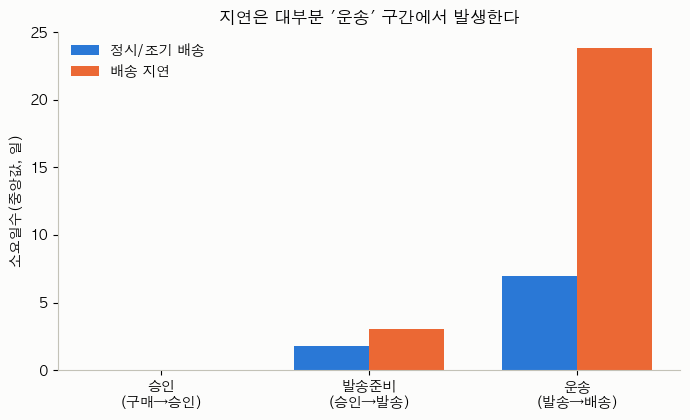

In [14]:
stage_df = stage_df.copy()
stage_df['total_elapsed'] = stage_df[stage_cols].sum(axis=1)
for grp, name in [(1,'지연'), (0,'정시')]:
    sub_g = stage_df[stage_df['is_delayed']==grp]
    shares = (sub_g[stage_cols].sum() / sub_g['total_elapsed'].sum() * 100).round(1)
    print(f"{name} 주문의 전체 소요시간 중 구간별 비중: "
          f"승인 {shares['approval_days']}%, 발송준비 {shares['carrier_prep_days']}%, 운송 {shares['transit_days']}%")

fig, ax = plt.subplots(figsize=(7,4.3))
labels = ["승인\n(구매→승인)","발송준비\n(승인→발송)","운송\n(발송→배송)"]
ont_vals = [stage_df.loc[stage_df.is_delayed==0, c].median() for c in stage_cols]
del_vals = [stage_df.loc[stage_df.is_delayed==1, c].median() for c in stage_cols]
x = np.arange(3); w=0.36
ax.bar(x-w/2, ont_vals, w, label="정시/조기 배송", color=BLUE)
ax.bar(x+w/2, del_vals, w, label="배송 지연", color=ORANGE)
ax.set_xticks(x); ax.set_xticklabels(labels); ax.set_ylabel("소요일수(중앙값, 일)")
ax.legend(frameon=False); ax.spines[['top','right']].set_visible(False)
ax.set_title("지연은 대부분 '운송' 구간에서 발생한다")
plt.tight_layout(); plt.show()


**Finding**: 운송(발송→배송) 구간의 Cliff's delta가 0.74로 압도적으로 크며(승인 0.08, 발송준비
0.29), 지연 주문의 운송 소요일 중앙값(23.9일)은 정시 주문(6.9일)의 3배 이상이다. 지연 주문에서
전체 소요시간 중 운송 구간이 차지하는 비중도 72%→81%로 확대된다. **지연은 판매자의 내부 처리
속도가 아니라 운송사의 실제 배송 구간에서 발생**한다.


## 8. 보조질문 2 — 카테고리별로 지연-리뷰 상관관계의 강도가 다른가

주문 수 상위 10개 카테고리(전체의 63.9% 커버)에 대해 카테고리별 효과크기를 비교하고,
회귀모형에 지연×카테고리 상호작용항을 넣어 그 차이가 통계적으로 유의한지 검정합니다
(F검정 결과는 §6에서 이미 확인: F=5.70, p<.001).

카테고리별로 유의성 검정을 각각 반복하면 다중비교 문제(우연히 유의해 보이는 결과가 늘어나는 문제)가 생기므로, 아래 카테고리별 수치는 **효과크기 비교(기술 통계)** 용도로만 사용하고, "카테고리에 따라 강도가 통계적으로 다른가"에 대한 판단은 §6의 상호작용항 검정(F=5.70, p<.001) 결과 하나에 근거합니다.


In [15]:
cat_stats = []
for c in top_cats:
    s_ = dfx[dfx['category']==c]
    d1 = s_.loc[s_['is_delayed']==1,'review_score']
    d0 = s_.loc[s_['is_delayed']==0,'review_score']
    if len(d1)<10 or len(d0)<10:
        continue
    Uc, pc = stats.mannwhitneyu(d1,d0, alternative='two-sided')
    delta_c = (2*Uc)/(len(d1)*len(d0)) - 1
    cat_stats.append({"category": c, "n": len(s_), "지연율(%)": round(s_['is_delayed'].mean()*100,2),
                       "평균(지연)": round(d1.mean(),3), "평균(정시)": round(d0.mean(),3),
                       "Cliff's delta": round(delta_c,4)})
cat_df = pd.DataFrame(cat_stats).sort_values("Cliff's delta")
cat_df["위험지수"] = (cat_df["지연율(%)"]/100 * (cat_df["평균(정시)"]-cat_df["평균(지연)"])).round(4)
cat_df.sort_values("위험지수", ascending=False)


,category,n,지연율(%),평균(지연),평균(정시),Cliff's delta,위험지수
6,watches_gifts,5433,8.39,2.421,4.280,-0.6005,0.1560
1,health_beauty,8570,8.82,2.652,4.386,-0.5544,0.1529
2,sports_leisure,7451,7.70,2.477,4.382,-0.5948,0.1467
9,toys,3754,7.30,2.387,4.387,-0.6270,0.1460
8,auto,3774,8.56,2.591,4.296,-0.5500,0.1459
0,bed_bath_table,9096,8.63,2.507,4.149,-0.5213,0.1417
4,furniture_decor,6155,8.50,2.566,4.216,-0.5291,0.1403
7,telephony,4050,8.49,2.692,4.186,-0.5068,0.1268
3,computers_accessories,6481,7.61,2.556,4.208,-0.5262,0.1257
5,housewares,5654,6.90,2.705,4.315,-0.5136,0.1111


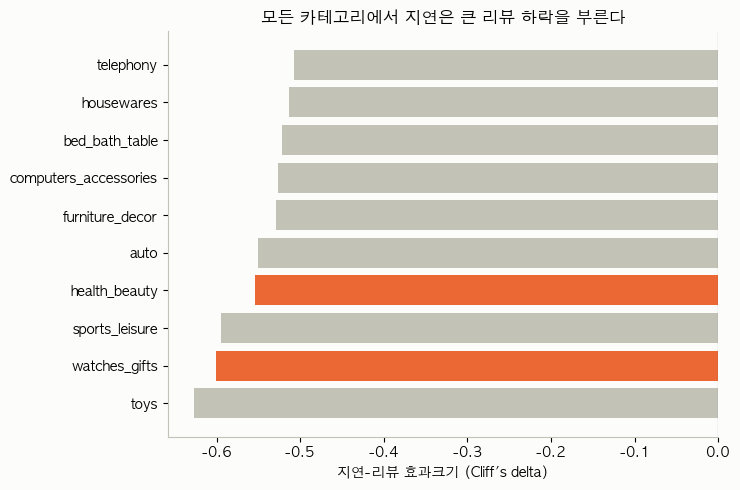

In [16]:
fig, ax = plt.subplots(figsize=(7.5,5))
plot_df = cat_df.sort_values("Cliff's delta")
colors = [ORANGE if r>plot_df["위험지수"].quantile(0.8) else GRAY for r in plot_df["위험지수"]]
ax.barh(plot_df['category'], plot_df["Cliff's delta"], color=colors)
ax.axvline(0, color=MUTED, linewidth=0.8)
ax.set_xlabel("지연-리뷰 효과크기 (Cliff's delta)")
ax.set_title("모든 카테고리에서 지연은 큰 리뷰 하락을 부른다")
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()


**Finding**: 상위 10개 카테고리 모두에서 Cliff's delta가 -0.51~-0.63으로 관례상 "large" 효과를
보이지만, §6의 상호작용 F검정(F=5.70, p<.001)이 보여주듯 그 강도 차이는 통계적으로 실재한다.
지연율과 점수 하락폭을 함께 고려한 "위험지수" 기준으로는 **시계·선물(watches_gifts), 뷰티·헬스
(health_beauty)** 카테고리가 가장 취약하다.


## 9. 외부 데이터 보강: 블랙프라이데이 캘린더가 배송 지연을 예측하는가

**왜 이게 "외부 데이터 보강"인가**: Olist 데이터셋 9개 테이블 어디에도 "오늘이 성수기인지"를 알려주는
컬럼은 없다. 아래 분석은 Olist 내부 주문 데이터(구매일시·지연 여부)에 **브라질의 공개된 공휴일·상업
기념일 캘린더**(블랙프라이데이·어머니날·연인의 날·어린이날·크리스마스 날짜)를 결합해야만 가능하다 —
내부 데이터만으로는 "11월 20일~12월 8일이 왜 위험한 구간인지" 자체를 알아낼 방법이 없다.

브라질의 블랙프라이데이는 미국 추수감사절(11월 넷째 주 목요일) 다음 날 날짜를 그대로 따른다.
날짜 계산으로 확정한 값은 **2016-11-25(금), 2017-11-24(금), 2018-11-23(금)**이다.

다만 전처리를 마친 분석 표본(delivered + 리뷰 매칭)의 구매일시 범위는
**2016-09-15 ~ 2018-08-29**다. 즉:
- **2016년**은 사업 초기 단계라 표본 전체가 264건뿐이라(대부분 10월) 블랙프라이데이·크리스마스 모두
  통계적으로 무의미해 이번 비교에서 제외한다.
- **2018년 11월은 표본에 존재하지 않는다**(구매일 최대치가 8/29) — 즉 이번 데이터로 검증 가능한
  블랙프라이데이는 **2017년 단 1회**뿐이다. 아래 결과는 이 점을 감안해 "1회 관측"이라는 한계를
  가진 채로 해석해야 한다.

비교 대상으로 블랙프라이데이 외에 브라질 이커머스 성수기로 흔히 언급되는 어머니날(5월 둘째 일요일),
연인의 날(6/12), 어린이날(10/12), 크리스마스(12/25)도 함께 검정해, "특정 날짜 부근이면 다 지연이
늘어난다"는 단순한 가정이 실제로 맞는지 확인한다.

In [17]:
df['purchase_date'] = df['order_purchase_timestamp'].dt.date
df['year'] = df['order_purchase_timestamp'].dt.year

events = {
    "블랙프라이데이 2017": "2017-11-24",
    "크리스마스 2017":     "2017-12-25",
    "어머니날 2017":       "2017-05-14",
    "어머니날 2018":       "2018-05-13",
    "연인의날 2017":       "2017-06-12",
    "연인의날 2018":       "2018-06-12",
    "어린이날 2017":       "2017-10-12",
}

WINDOW = 7  # 일 단위, 이벤트 날짜 ±7일을 '이벤트 구간'으로 정의
event_rows = []
for name, date_str in events.items():
    ev_date = pd.Timestamp(date_str).date()
    yr = ev_date.year
    sub = df[df['year'] == yr].copy()

    # 구간(윈도우)은 연도 경계와 무관하게 df 전체에서 잡는다 — 연도로 먼저 자르면
    # 크리스마스처럼 창이 다음 해로 넘어가는 이벤트의 날짜가 잘려나간다.
    in_window_full = (df['purchase_date'] >= ev_date - pd.Timedelta(days=WINDOW)) & \
                     (df['purchase_date'] <= ev_date + pd.Timedelta(days=WINDOW))
    win = df[in_window_full]

    # 연간 비교군(ctrl)은 그 해(sub) 안에서 구간에 해당하는 날짜만 제외한다.
    in_window_year = (sub['purchase_date'] >= ev_date - pd.Timedelta(days=WINDOW)) & \
                     (sub['purchase_date'] <= ev_date + pd.Timedelta(days=WINDOW))
    ctrl = sub[~in_window_year]

    ct = pd.DataFrame({
        0: [(win['is_delayed']==0).sum(), (ctrl['is_delayed']==0).sum()],
        1: [(win['is_delayed']==1).sum(), (ctrl['is_delayed']==1).sum()],
    }, index=['구간','연간(구간 제외)'])
    chi2, p_chi, dof, exp = chi2_contingency(ct)
    daily_avg_year   = len(sub) / sub['purchase_date'].nunique()
    daily_avg_window = len(win) / (2*WINDOW+1)

    event_rows.append({
        "이벤트": name, "기준일": date_str,
        "구간 n": len(win), "연간 n": len(sub),
        "구간 지연율(%)": round(win['is_delayed'].mean()*100, 2),
        "연간 지연율(%)": round(ctrl['is_delayed'].mean()*100, 2),
        "주문량 증폭(x)": round(daily_avg_window/daily_avg_year, 2),
        "chi2 p": p_chi,
    })

event_df = pd.DataFrame(event_rows)
print(f"※ 2016년(표본 264건)·2018년 11월(표본 없음)은 제외 — 블랙프라이데이는 2017년 1회만 검증 가능\n")
print(event_df.to_string(index=False))


※ 2016년(표본 264건)·2018년 11월(표본 없음)은 제외 — 블랙프라이데이는 2017년 1회만 검증 가능

         이벤트        기준일  구간 n  연간 n  구간 지연율(%)  연간 지연율(%)  주문량 증폭(x)        chi2 p
블랙프라이데이 2017 2017-11-24  4967 43098      17.94       5.02       2.77 1.209636e-263
  크리스마스 2017 2017-12-25  1863 43098       5.21       6.57       1.04  2.272620e-02
   어머니날 2017 2017-05-14  1752 43098       3.65       6.63       0.98  9.710166e-07
   어머니날 2018 2018-05-13  3942 52462      11.26       9.09       1.21  6.579576e-06
   연인의날 2017 2017-06-12  1680 43098       3.99       6.61       0.94  2.427270e-05
   연인의날 2018 2018-06-12  3161 52462       1.87       9.72       0.97  3.122292e-49
   어린이날 2017 2017-10-12  2232 43098       5.73       6.55       1.25  1.395144e-01


**판단/Finding**: 검정한 7개 이벤트-연도 조합 중 **블랙프라이데이 2017만 뚜렷하고 강한 효과**를
보인다 — 이벤트 구간(±7일) 지연율이 17.94%로 나머지 기간(5.02%)의 3.5배이며 주문량도 평시의
2.77배로 급증했다(χ² p≈1.2×10⁻²⁶³). 반면 크리스마스·어머니날·연인의날·어린이날은 주문량 증폭이
거의 없거나(0.94~1.25배) 오히려 구간 지연율이 연간 평균보다 **낮은** 경우도 있었다(예: 연인의날
2018은 1.87% vs 9.72%). 즉 "특정 기념일 근처면 지연이 늘어난다"는 가정은 일반화할 수 없고,
**단기간에 폭발적 주문량 증가를 유발하는 블랙프라이데이형 이벤트**만이 운송 지연과 뚜렷하게
연결된다고 보는 것이 데이터에 더 부합한다. (크리스마스처럼 배송 마감이 있는 기념일은 구매가
기준일 이전 몇 주에 걸쳐 분산되므로, 기준일 ±7일 창이 실제 성수기 발송 부담을 온전히 포착하지
못했을 가능성도 있다 — 후속 분석에서 창을 이벤트 이전으로 비대칭 확장해 재검정할 필요가 있다.)

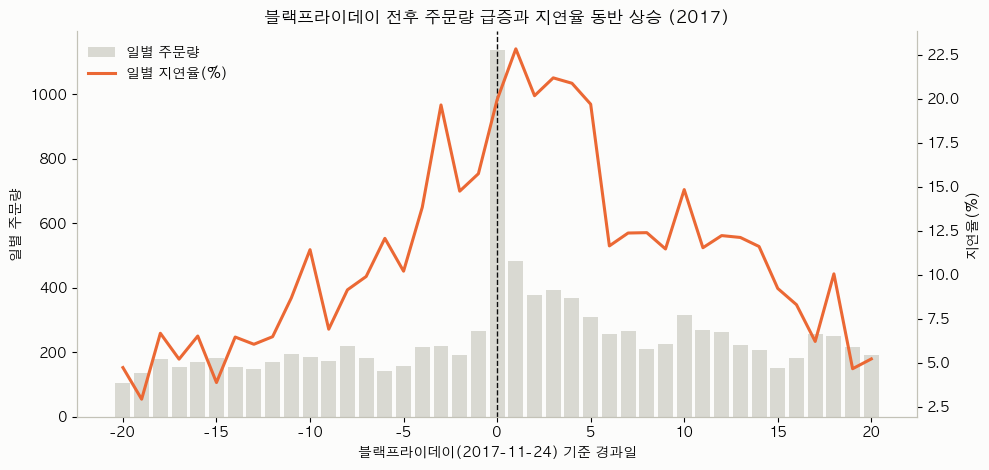

당일(0일) 지연율=19.9%, +1일=22.8% (정점).
고원 구간(-4~+14일) 지연율 범위: 11.5%~22.8%.
고원 이전(-20~-5일) 평균 지연율=7.3%, +17일 이후(+18~+20일) 평균=6.6%로 평시 수준 복귀.


In [18]:
# 2017년 블랙프라이데이 전후 ±20일 일별 추이 — 언제부터 언제까지 지연 위험이 높아지는지 확인
ev = pd.Timestamp("2017-11-24").date()
daily = df[(df['purchase_date'] >= ev - pd.Timedelta(days=20)) &
           (df['purchase_date'] <= ev + pd.Timedelta(days=20))].copy()
daily['블프_기준_경과일'] = daily['purchase_date'].apply(lambda d: (d - ev).days)
daily_agg = (daily.groupby('블프_기준_경과일')
                   .agg(n=('is_delayed','size'), 지연율=('is_delayed','mean'))
                   .reset_index())

fig, ax1 = plt.subplots(figsize=(10,4.8))
ax1.bar(daily_agg['블프_기준_경과일'], daily_agg['n'], color=GRAY, alpha=0.6, label="일별 주문량")
ax1.set_xlabel("블랙프라이데이(2017-11-24) 기준 경과일"); ax1.set_ylabel("일별 주문량")
ax1.axvline(0, color=INK, linestyle='--', linewidth=1)

ax2 = ax1.twinx()
ax2.plot(daily_agg['블프_기준_경과일'], daily_agg['지연율']*100, color=ORANGE, linewidth=2.2, label="일별 지연율(%)")
ax2.set_ylabel("지연율(%)")

ax1.spines[['top']].set_visible(False); ax2.spines[['top']].set_visible(False)
fig.legend(loc='upper left', bbox_to_anchor=(0.08,0.92), frameon=False)
ax1.set_title("블랙프라이데이 전후 주문량 급증과 지연율 동반 상승 (2017)")
plt.tight_layout(); plt.show()

day0 = daily_agg.loc[daily_agg['블프_기준_경과일']==0, '지연율'].values[0]*100
day1 = daily_agg.loc[daily_agg['블프_기준_경과일']==1, '지연율'].values[0]*100
plateau = daily_agg[(daily_agg['블프_기준_경과일']>=-4) & (daily_agg['블프_기준_경과일']<=14)]['지연율']
before = daily_agg[daily_agg['블프_기준_경과일']<-4]['지연율']
after  = daily_agg[daily_agg['블프_기준_경과일']>17]['지연율']
print(f"당일(0일) 지연율={day0:.1f}%, +1일={day1:.1f}% (정점).")
print(f"고원 구간(-4~+14일) 지연율 범위: {plateau.min()*100:.1f}%~{plateau.max()*100:.1f}%.")
print(f"고원 이전(-20~-5일) 평균 지연율={before.mean()*100:.1f}%, +17일 이후(+18~+20일) 평균={after.mean()*100:.1f}%로 평시 수준 복귀.")

**Finding**: 지연율은 블랙프라이데이 당일(-0)과 다음날(+1)에 정점(19.9%, 22.8%)을 찍고, **경과일
-4일부터 +14일까지 약 3주간 11~23% 수준의 고원(plateau)**을 형성한 뒤 +17일 이후 평시 수준(5~6%)
으로 되돌아온다. 달리 말해 2017년 데이터 기준으로 **11/20~12/8 사이에 구매된 주문은 예상보다
훨씬 자주 늦게 도착**했다. 이는 단일 성수기 이벤트를 겨냥한 운송사 SLA 가산 조항(예: 해당 3주
구간에 한해 처리 용량 사전 확보 또는 지연 허용 기준 완화)의 구체적 시작·종료일을 데이터로
뒷받침할 수 있다는 뜻이다 — 다만 **관측된 사이클이 1회뿐**이라는 한계는 반복해서 강조할 필요가
있다.

### 9-1. 외부 데이터 보강 체크리스트 (발표자료 부록용)

| 항목 | 내용 |
|---|---|
| 외부 데이터 | 브라질 공휴일·상업 기념일 캘린더 (블랙프라이데이·어머니날·연인의날·어린이날·크리스마스 날짜) |
| 수집 방식 | 날짜 계산(블랙프라이데이 = 미국 추수감사절 다음 날) 및 공개적으로 알려진 브라질 기념일 날짜 사용 — **웹 스크래핑을 수행하지 않음** |


## 9-2. 후속 분석 — 블랙프라이데이 말고, 또 다른 스파이크가 있었다

§9 분석을 마친 뒤 전체 기간 월별 지연율을 다시 훑어보다가 발견했다. **이름 붙은 성수기 이벤트가
아닌데도 2018년 2~3월 두 달간** 지연율이 블랙프라이데이급으로 치솟았다. 아래에서는 이 스파이크가
특정 지역·판매자·상품 구성·운영 판단 오류 때문인지 하나씩 소거법으로 점검한다.

     ym    n  지연율(%)
2017-01  741    2.97
2017-02 1643    2.80
2017-03 2527    5.50
2017-04 2290    7.73
2017-05 3517    3.44
2017-06 3111    3.79
2017-07 3842    3.36
2017-08 4165    3.31
2017-09 4118    5.12
2017-10 4446    5.15
2017-11 7237   14.15
2017-12 5461    8.26
2018-01 7013    6.49
2018-02 6507   15.89
2018-03 6948   21.06
2018-04 6752    5.20
2018-05 6722    8.18
2018-06 6072    1.37
2018-07 6118    4.35
2018-08 6330   10.28


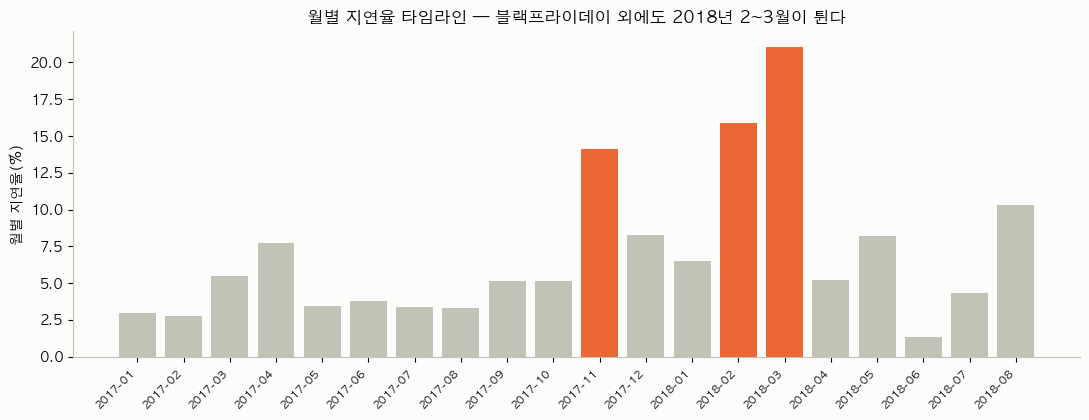

In [19]:
df['ym'] = df['order_purchase_timestamp'].dt.to_period('M').astype(str)

# §9와 동일한 기준: 2016년은 표본이 극히 적어(264건) 시각적 왜곡만 키우므로 이 타임라인에서는 제외
monthly = (df[df['year'] >= 2017]
           .groupby('ym').agg(n=('is_delayed', 'size'), 지연율=('is_delayed', 'mean'))
           .reset_index())
monthly['지연율(%)'] = (monthly['지연율'] * 100).round(2)
print(monthly[['ym', 'n', '지연율(%)']].to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 4.3))
highlight = {'2017-11', '2018-02', '2018-03'}
colors = [ORANGE if m in highlight else GRAY for m in monthly['ym']]
ax.bar(monthly['ym'], monthly['지연율(%)'], color=colors)
ax.set_xticklabels(monthly['ym'], rotation=45, ha='right', fontsize=8)
ax.set_ylabel("월별 지연율(%)")
ax.set_title("월별 지연율 타임라인 — 블랙프라이데이 외에도 2018년 2~3월이 튄다")
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()

**판단**: 2018년 2~3월 지연율(각각 15.89%, 21.06%)은 블랙프라이데이 2017 구간(17.94%)과 맞먹는
수준이다. 규모가 유사하므로, §9에서 잠시 제쳐두었던(§0-1 참고: "이번 3가지 질문에는 거리·지역
변수가 포함되지 않아 사용하지 않는다") `customers`·`sellers`의 지역 정보를 지금 불러와 원인을
하나씩 소거해본다.

In [20]:
# 원인 점검 1 — 지역(고객 주) 문제인가?
df = df.merge(customers[['customer_id', 'customer_state']], on='customer_id', how='left')

# 판매자 주(발송지 프록시) — 아이템 금액 비중이 가장 큰 판매자를 대표 판매자로 선정
items_seller = items.merge(sellers[['seller_id', 'seller_state']], on='seller_id', how='left')
items_seller['item_total'] = items_seller['price'] + items_seller['freight_value']
seller_val = items_seller.groupby(['order_id', 'seller_state'])['item_total'].sum().reset_index()
primary_seller_state = (seller_val.sort_values('item_total', ascending=False)
                                   .groupby('order_id').head(1)[['order_id', 'seller_state']])
df = df.merge(primary_seller_state, on='order_id', how='left')

df['is_q1_2018'] = df['ym'].isin(['2018-02', '2018-03'])
q1, base = df[df['is_q1_2018']], df[~df['is_q1_2018']]
print(f"2018-02~03      : n={len(q1):,}, 지연율={q1['is_delayed'].mean()*100:.2f}%, "
      f"평균리뷰={q1['review_score'].mean():.3f}")
print(f"나머지 기간      : n={len(base):,}, 지연율={base['is_delayed'].mean()*100:.2f}%, "
      f"평균리뷰={base['review_score'].mean():.3f}")

sp_cust = df[df['customer_state'] == 'SP']
print(f"\nSP(허브) 고객 지연율   — 평소 {sp_cust[~sp_cust.is_q1_2018].is_delayed.mean()*100:.1f}% "
      f"→ Q1 {sp_cust[sp_cust.is_q1_2018].is_delayed.mean()*100:.1f}%")
for st in ['CE', 'MA', 'AL', 'RJ']:
    sub = df[df['customer_state'] == st]
    print(f"{st} 고객 지연율        — 평소 {sub[~sub.is_q1_2018].is_delayed.mean()*100:.1f}% "
          f"→ Q1 {sub[sub.is_q1_2018].is_delayed.mean()*100:.1f}% (n_Q1={sub[sub.is_q1_2018].shape[0]})")

sp_sell = df[df['seller_state'] == 'SP']
print(f"\nSP 발송 건 지연율      — 평소 {sp_sell[~sp_sell.is_q1_2018].is_delayed.mean()*100:.1f}% "
      f"→ Q1 {sp_sell[sp_sell.is_q1_2018].is_delayed.mean()*100:.1f}% "
      f"(전체 발송 중 SP 비중 {len(sp_sell)/len(df)*100:.1f}%)")

2018-02~03      : n=13,455, 지연율=18.56%, 평균리뷰=3.846
나머지 기간      : n=82,369, 지연율=6.27%, 평균리뷰=4.207

SP(허브) 고객 지연율   — 평소 5.1% → Q1 10.2%
CE 고객 지연율        — 평소 9.9% → Q1 48.3% (n_Q1=176)
MA 고객 지연율        — 평소 14.9% → Q1 44.7% (n_Q1=103)
AL 고객 지연율        — 평소 21.1% → Q1 37.7% (n_Q1=53)
RJ 고객 지연율        — 평소 9.6% → Q1 36.0% (n_Q1=1717)

SP 발송 건 지연율      — 평소 6.7% → Q1 20.4% (전체 발송 중 SP 비중 70.9%)


**소거 결과 1**: 특정 지역만의 문제가 아니다. 허브인 SP(상파울루) 고객·판매자 모두 지연율이
2배 가까이 뛰었고, 원거리 지역(CE·MA·RJ 등)은 3~4배까지 뛰었다 — **전국적으로 확산되었고, 원거리일수록
더 심하다.** 전체 발송의 다수를 차지하는 SP발 건 자체가 나빠졌으므로 "특정 소규모 판매자 탓"으로도
보기 어렵다.

In [21]:
# 원인 점검 2 — 상품 구성이 바뀌어서인가? / 원인 점검 3 — 예상배송일을 잘못 산정해서인가?
comp = (df.groupby('is_q1_2018')['category'].value_counts(normalize=True)
          .unstack(level=0) * 100)
comp.columns = ['평소', 'Q1_2018']
comp['diff'] = (comp['Q1_2018'] - comp['평소']).round(2)
print("카테고리 비중 변화 상위 5개(비중 차이 기준):")
print(comp.sort_values('diff', ascending=False).head(5).round(2).to_string())

df['estimated_days'] = (df['order_estimated_delivery_date'] - df['order_purchase_timestamp']).dt.total_seconds() / 86400
df['actual_days'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.total_seconds() / 86400
est_cmp = df.groupby('is_q1_2018')[['estimated_days', 'actual_days']].mean().round(2)
est_cmp.index = ['평소', 'Q1_2018']
print("\n예상배송일 vs 실제배송일 평균(일):")
print(est_cmp.to_string())

카테고리 비중 변화 상위 5개(비중 차이 기준):
                         평소  Q1_2018  diff
category                                  
computers_accessories  6.24    10.66  4.42
electronics            2.40     4.01  1.61
sports_leisure         7.69     9.11  1.42
auto                   3.89     4.62  0.72
telephony              4.20     4.84  0.65

예상배송일 vs 실제배송일 평균(일):
         estimated_days  actual_days
평소                23.81        11.86
Q1_2018           23.24        16.56


**소거 결과 2·3**: 카테고리 비중 차이는 최대 4.4%p 수준으로 미미해 상품 구성 변화로 보기 어렵다.
예상배송일은 23.8일→23.2일로 거의 동일한데 실제 배송일만 11.9일→16.6일로 늘었다 — **운영진이
배송 예정일을 짧게 잘못 잡은 것이 아니라, 약속은 평소대로 했는데 실행(실제 배송)만 느려졌다.**

           승인  발송준비     운송
평소       0.01  1.80   6.98
Q1_2018  0.01  2.11  10.59


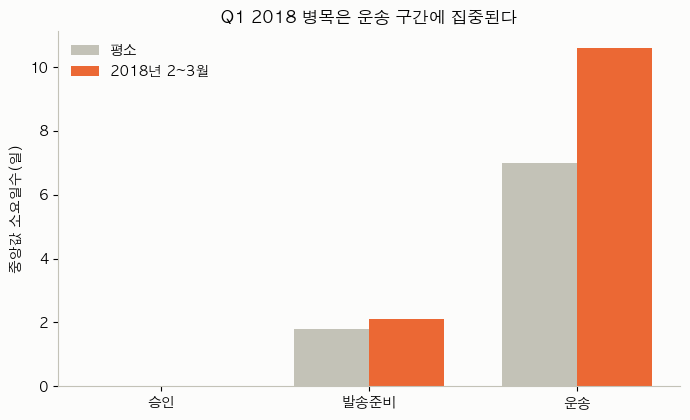

In [22]:
# 원인 점검 4 — 어느 배송 단계에서 발생했나? (§7의 stage_df 재사용)
stage_df['ym'] = stage_df['order_purchase_timestamp'].dt.to_period('M').astype(str)
stage_df['is_q1_2018'] = stage_df['ym'].isin(['2018-02', '2018-03'])

stage_cmp = stage_df.groupby('is_q1_2018')[stage_cols].median().round(2)
stage_cmp.index = ['평소', 'Q1_2018']
stage_cmp.columns = ['승인', '발송준비', '운송']
print(stage_cmp.to_string())

fig, ax = plt.subplots(figsize=(7, 4.3))
x = np.arange(3); w = 0.36
ax.bar(x - w/2, stage_cmp.loc['평소'], w, label='평소', color=GRAY)
ax.bar(x + w/2, stage_cmp.loc['Q1_2018'], w, label='2018년 2~3월', color=ORANGE)
ax.set_xticks(x); ax.set_xticklabels(['승인', '발송준비', '운송'])
ax.set_ylabel("중앙값 소요일수(일)")
ax.legend(frameon=False); ax.spines[['top', 'right']].set_visible(False)
ax.set_title("Q1 2018 병목은 운송 구간에 집중된다")
plt.tight_layout(); plt.show()

**Finding**: 승인(0.01→0.01일)과 발송준비(1.80→2.11일)는 거의 그대로인데, **운송 구간만 중앙값
6.98일→10.59일로 급증**했다. 지역·판매자·상품 구성·예상배송일 산정 오류는 모두 배제됐고, 규모(지연율
18.56%, n=13,455)는 블랙프라이데이 2017(17.94%)과 맞먹는다. 종합하면 특정 주체의 잘못이라기보다
**2018년 2~3월 전국 단위의 라스트마일 운송 병목**으로 보인다.

**한계 — 원인 미확인**: 이 노트북에 포함된 데이터(주문·리뷰·상품·판매자·결제·위치 정보)만으로는
**왜** 이 두 달간 전국적으로 운송이 느려졌는지 알 수 없다. 외부 뉴스·업계 자료 등 별도 조사가
필요한 영역이며, 이번 분석에서는 원인을 추정하지 않고 데이터로 확인된 패턴까지만 보고한다.

## 10. Findings → Insights → Recommendations 요약

### Findings (발견)
1. 지연 주문의 평균 리뷰 점수는 2.57점으로 정시 주문(4.29점)보다 크게 낮다 (Cliff's δ=-0.55, large, p<.001).
   지연 *여부*(이진)의 효과가 지연 *일수*(연속)의 효과(Spearman ρ=-0.18)보다 훨씬 크다.
2. 지연에 대한 기여도는 운송 구간(δ=0.74)이 발송준비(δ=0.29), 승인(δ=0.08)보다 압도적으로 크다.
3. 모든 상위 카테고리에서 지연-리뷰 효과는 크지만(δ -0.51~-0.63), 그 강도 차이는 통계적으로 유의하다
   (상호작용 F=5.70, p<.001) — 시계·선물, 뷰티·헬스가 위험지수 상위.
4. **(외부 데이터 보강)** 성수기 캘린더 중 **블랙프라이데이만** 지연과 뚜렷하게 연결된다. 2017년
   블랙프라이데이 전후 3주(-4~+14일)간 지연율이 평시 대비 최대 3.5배(17.9% vs 5.0%, 주문량 2.77배
   급증, χ² p≈1.2×10⁻²⁶³)로 치솟았다. 크리스마스·어머니날·연인의날·어린이날은 같은 패턴을 보이지
   않았다(다만 이는 데이터에서 관측된 **블랙프라이데이 1회 사이클**에 근거한다).
5. **(후속 분석)** 이름 붙은 이벤트가 없는데도 **2018년 2~3월** 지연율이 18.56%(n=13,455)로
   블랙프라이데이 2017(17.94%)급 수준까지 치솟았다. 지역·판매자·상품 구성·예상배송일 산정 오류를
   모두 소거했고, 운송 구간(중앙값 6.98→10.59일)에서 전국적으로 발생했다는 것까지는 확인했지만
   실제 외부 원인은 이 데이터만으로 확인되지 않는다.

### Insights (인사이트)
1. 고객은 "약속을 지켰는가"라는 이분법적 신뢰 문제로 반응한다 — 배송 최적화의 목표는 평균 배송일
   단축이 아니라 **정시율(예상배송일 준수율)** 자체여야 한다.
2. 지연의 81%가 Olist/판매자가 아닌 **운송사 구간**에서 발생한다 — 판매자를 다그치는 것보다 운송사
   성과 관리가 훨씬 큰 레버리지를 가진다. 다만 공개 데이터에는 운송사 식별자가 익명 처리되어 있어,
   "어느 운송사인가"는 특정하지 못하고 "어디서 발생하는가(구간)"까지만 특정할 수 있다.
3. 선물·뷰티처럼 "기대치가 높은" 카테고리는 같은 지연에도 리뷰 타격이 크다 — 전사 일괄 대응보다
   카테고리별 우선순위가 필요하다.
4. 지연 리스크는 연중 균일하지 않다 — 블랙프라이데이 같은 **폭발적 수요 집중 이벤트** 전후 3주가
   다른 어떤 기념일보다도 압도적으로 큰 위험 구간이다. 성수기 대응은 "11월 한 달 전체"보다 이
   구체적 3주 창에 자원을 집중하는 것이 효율적이다.
5. "알려진 이벤트만 캘린더에 넣고 대비하는" 방식은 구조적 한계가 있다 — 2018년 2~3월처럼 **이름
   없는 병목**이 이름 있는 성수기(블랙프라이데이)만큼 큰 피해를 줄 수 있다.

### Recommendations (제언)
1. **물류팀**이 **1개월 내** 판매자 주(state)→고객 주(state) 노선 프록시로 위험 구간 우선순위를
   확정하고, **3개월 내(다음 계약 갱신 전)** 운송사 식별 정보(계약사명 등)를 Olist 또는 내부
   정산·계약 데이터를 통해 확보한다 — 공개 데이터셋에는 이 정보가 익명 처리되어 있어 운송사 단위
   SLA 협상이 원천적으로 막혀 있기 때문이다. 기대효과: 지연율(현재 8.0%) 감소를 통한 리뷰 개선.
2. **오퍼레이션팀**이 **다음 분기 착수**로 예상배송일 산정 로직에 **11/20~12/8(2017년 관측 기준
   블랙프라이데이 고위험 구간)** 성수기 버퍼를 반영하고, 해당 구간에 한해 운송사와 사전 용량 확보를
   협의한다. **CX팀**은 **즉시** 위험지수 상위 카테고리(시계·선물, 뷰티·헬스) 판매자에 배송 SLA
   모니터링을 적용한다. 기대효과: 성수기 지연율 완화 및 고위험 카테고리의 리뷰 추가 하락 방지.
3. **오퍼레이션팀**이 **다음 블랙프라이데이 시즌 데이터 확보 즉시(2018년 11월 이후 데이터 입수
   시점)** "3주 고위험 구간"이 매년 반복되는 패턴인지 재검증한다 — 1회 관측만으로 상시 정책화하기
   전에 최소 1~2개 사이클을 더 확인하는 것이 안전하다. 기대효과: 성수기 버퍼 정책의 오탐(불필요한
   상시 적용에 따른 운영 비용 낭비) 방지.
4. **오퍼레이션팀**이 **즉시** 월별(가능하면 주별) 지연율 대시보드를 구축하고 평시 대비 일정 배수를
   초과하면 자동 알림이 오도록 한다. 기대효과: 2018년 2~3월급 "이름 없는" 병목을 조기에 포착해
   원인 파악·대응까지의 리드타임을 단축.

## 11. 한계 및 후속 분석 제안

- **상관≠인과**: 관측 데이터 기반 분석이다. 회귀에서 통제한 변수(카테고리·가격·할부)만으로는
  판매자 CS 품질, 상품 실제 파손·품질 이슈 등 미관측 교란을 배제할 수 없다.
- **리뷰는 다요인 결과물**: 리뷰 점수는 배송 외에도 상품 품질, 가격 대비 만족도 등의 영향을 받는다.
  "지연이 유일한 원인"이라 단정하지 않는다.
- **카테고리 분석의 커버리지**: 상위 10개 카테고리(전체의 63.9%)로 한정했다. 표본이 적은 카테고리는
  신뢰도 있는 비교가 어려워 제외했다.
- **운송사 식별 정보 익명화**: Olist 공개 데이터셋은 판매자(`seller_id`)와 배송 관련 날짜는 제공하지만,
  실제 배송을 수행하는 운송사(택배사) 식별자는 9개 테이블 어디에도 포함되어 있지 않다 — 단순 결측이
  아니라 사실상 익명·비공개 처리된 것으로 보인다(경쟁 운송사 정보 노출 방지 등 상업적 이유로 추정).
  그래서 "어느 운송사가 지연의 원인인가"는 이번 공개 데이터만으로는 원천적으로 답할 수 없고, "어느
  구간(승인/발송준비/운송)에서 발생하는가"까지만 특정할 수 있다.
- **캘린더 분석의 표본 한계**: 전처리 후 표본의 구매일시가 2016-09-15~2018-08-29로 한정되어,
  블랙프라이데이는 **2017년 단 1회**만 검증할 수 있었다. 2016년(264건)과 2018년 11월(표본 없음)은
  제외했다. 따라서 §9의 "3주 고위험 구간"은 방향성 있는 신호이지 확정된 계절 패턴은 아니다 —
  추가 연도 데이터로 재검증이 필요하다. 또한 크리스마스 등 배송 마감형 기념일은 ±7일 창이 실제
  성수기 발송 부담(구매가 기준일 이전 몇 주에 분산됨)을 온전히 포착하지 못했을 수 있어, 창을
  비대칭으로 넓혀 재검정하는 것이 다음 단계로 유효하다.
- **2018년 2~3월 병목의 외부 원인 미확인**: §9-2에서 지역·판매자·상품 구성·예상배송일 산정 오류는
  모두 배제했고 운송 구간에서 전국적으로 발생했다는 것까지는 확인했지만, 실제 외부 원인(물류 업계
  이슈, 정책 변화 등)은 이 데이터셋만으로 알 수 없다. 외부 자료 조사가 필요하다.
- **후속 분석 제안**: (1) 운송사 식별 정보를 내부 계약·정산 데이터로 확보해 §7·§8의 구간·카테고리
  분석을 실제 운송사 단위로 재검증(그 전까지는 판매자 주→고객 주 노선을 임시 프록시로 활용), (2)
  2018년 11월 이후 데이터를 추가 확보해 블랙프라이데이 3주 고위험 구간이 매년 반복되는지 재검증,
  (3) 크리스마스 등 배송 마감형 기념일은 구매 시점을 기준일 이전으로 비대칭 확장한 창으로 재분석,
  (4) 2018년 2~3월 병목의 실제 원인을 외부 뉴스·업계 자료로 조사.